# 02 — Inspección de muones desde el binario DAT

## Contexto físico

**Lo que simula CORSIKA**: cuando un rayo cósmico primario (acá un protón, ID=14) entra a la atmósfera, choca con un núcleo de aire y produce una cascada de partículas secundarias: π⁺, π⁻, K⁺, K⁻, etc. Estas partículas pueden:

1. **Interactuar de nuevo** con la atmósfera → más cascada.
2. **Decaer**. Es acá donde nacen los muones: π⁺ → μ⁺ + ν_μ, π⁻ → μ⁻ + ν̄_μ.

Los **muones** son hermanos pesados del electrón (200× más masa) y casi no interactúan con materia → atraviesan **kilómetros de roca**. Esa propiedad es la base de la **muografía**: medimos cuántos muones atraviesan un volcán y comparamos con cuántos esperaríamos sin volcán. La diferencia da el mapa de densidades del edificio.

## Qué vamos a hacer en este notebook

Levantamos el binario `DAT001NNNN` (output crudo de CORSIKA) y miramos, para cada muon que llegó al nivel de observación (OBSLEV):

- Su **carga** (μ⁺ o μ⁻).
- Su **energía cinética** (GeV).
- Su **dirección**: ángulo cenital θ (0 = vertical, 90 = horizontal) y azimutal φ.
- Su **posición** (x, y) en el plano del OBSLEV.
- Su **tiempo de llegada** (ns desde el inicio del shower).

Cada sección abajo responde una pregunta concreta y dice **qué buscar** para validar que el resultado tiene sentido físico.

**Pre-requisitos** (una vez, en tu env conda):
```bash
pip install corsikaio pandas matplotlib numpy
```

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from analysis.corsika import CorsikaRun, PARTICLE_NAMES

In [6]:
# RUNNR de la corrida de Fuego que queremos inspeccionar. Cambialo al RUNNR
# que tengas localmente (ver `make runs` para la lista del manifest, o
# `cat sim/runs.csv`).
RUNNR_MAIN = 5

# Cambiar run_number según qué corrida querramos inspeccionar:
#   1001 = fuego_test  (500 showers)
#   1101 = fuego_prod  (50,000 showers)
run = CorsikaRun(REPO_ROOT / "sim" / "output", run_number=RUNNR_MAIN)
md = run.lst.metadata()
print(f"RUNNR={md.run_number}, primario={md.primary_name} (id={md.primary_id}), "
      f"E ∈ [{md.energy_min_gev:.0f}, {md.energy_max_gev:.0e}] GeV, "
      f"θ ∈ [{md.theta_min_deg}, {md.theta_max_deg}]°, "
      f"OBSLEV={md.obslev_cm/1e5:.2f} km")

RUNNR=14, primario=p (id=14), E ∈ [10, 1e+05] GeV, θ ∈ [0.0, 89.0]°, OBSLEV=2.00 km


## Parámetros físicos de la simulación

Antes de mirar el contenido del binario, recordamos qué se le pidió a CORSIKA. Algunos parámetros vienen del steering del run (`fuego_prod.inp`, `fuego_template.inp`); otros se fijan al **compilar** la imagen Docker (los modelos hadrónicos, el modo curvo, el seguimiento de muones decaídos). Todo esto queda registrado en el `.lst`, así que la siguiente celda parsea el `.lst` del run cargado y arma la tabla.

La justificación de **por qué** se eligieron estos modelos está en `sim/MODELOS.md`. Cada categoría de la tabla apunta a una sección de ese documento.


In [7]:
import re
from IPython.display import Markdown, display

lst_text = run.lst.path.read_text() if run.has_lst else ''

def _grep(pattern: str, default: str = 'no encontrado') -> str:
    m = re.search(pattern, lst_text, re.MULTILINE)
    return m.group(1).strip() if m else default

# Modelos hadrónicos: la imagen 7.8050 reporta el HE/LE en líneas como
#   'DPMJET TREATS HIGH ENERGY HADRONIC INTERACTIONS'
#   'URQMD TREATS LOW ENERGY HADRONIC INTERACTIONS'
he_model = _grep(r'^\s*(\S+)\s+TREATS HIGH ENERGY HADRONIC INTERACTIONS', 'desconocido')
le_model = _grep(r'^\s*(\S+)\s+TREATS LOW ENERGY HADRONIC INTERACTIONS', 'desconocido')
transition_gev = _grep(r'HIGH ENERGY INTERACTION MODEL USED ABOVE\s+([\d.]+)\s+GEV', '?')
em_model = 'EGS4' if 'EGS4' in lst_text else _grep(r'ELECTROMAGNETIC COMPONENT SIMULATED WITH\s+(\S+)')
is_curved = 'CURVED VERSION' in lst_text
is_muprod = 'HISTORY OF DECAYING MUONS' in lst_text or 'MUPROD' in lst_text

# Atmósfera y campo magnético
atm_desc = _grep(r'\(\s*(US STANDARD ATMOSPHERE[^)]*)\)', 'desconocida')
B_total = _grep(r'EARTH MAGNETIC FIELD STRENGTH IS\s+([\d.E+-]+)', '?')
B_incl  = _grep(r'WITH INCLINATION ANGLE\s+([\d.E+-]+)', '?')

# Cortes de energía: línea ECUTS del steering eco-eada en el .lst
ecuts = _grep(r'^\s*ECUTS\s+([\d.eE+\-\s]+?)\s*$', '?')

# Geometría
obslev_km = md.obslev_cm / 1e5 if md.obslev_cm else None
obslev_xv = md.obslev_gcm2

tbl = f'''
| Categoría | Parámetro | Valor | Detalle |
|---|---|---|---|
| **Geometría** | OBSLEV | {obslev_km:.2f} km ({obslev_xv:.0f} g/cm²) | Flanco N de Acatenango, mira al Fuego |
|  | θ (cenital) | {md.theta_min_deg:.0f}° – {md.theta_max_deg:.0f}° | Cobertura completa, incluye régimen muografía θ>70° |
|  | φ (azimutal) | {md.phi_min_deg:.0f}° – {md.phi_max_deg:.0f}° | Isotrópico; el corte al volcán se hace en post |
|  | Atmósfera | {atm_desc} | ATMOD=1; suficiente para validación, no estacional |
|  | Campo magnético | {B_total} µT, inclinación {B_incl}° | Aproximación IGRF-13 en Fuego (14.5°N, 90.9°W) |
|  | Modo de trazado | {'CURVED' if is_curved else 'planar'}{' + MUPROD' if is_muprod else ''} | Curvo es obligatorio para θ>70° |
| **Primario** | Partícula | proton (id={md.primary_id}) | ~85% del flujo de rayos cósmicos primarios |
|  | Espectro diferencial | dN/dE ∝ E^{md.spectral_slope:.1f} | Ley de potencias estándar debajo del *knee* |
|  | Rango de energía | {md.energy_min_gev:.0f} GeV – {md.energy_max_gev:.0e} GeV | Cubre régimen de muones que penetran el edificio del Fuego |
| **Modelos hadrónicos** | Alta energía (>{transition_gev} GeV) | {he_model} | Modelo de referencia LHC; ver sim/MODELOS.md §HE |
|  | Baja energía (<{transition_gev} GeV) | {le_model} | Sirve para hadrones secundarios del shower |
|  | Electromagnético | {em_model} | Cascada e±/γ; estándar de facto |
| **Cortes (ECUTS)** | hadr / μ / e / γ | {ecuts} GeV | Por debajo de estos cortes la partícula deja de seguirse |
| **Output de muones** | MUADDI | T | Guarda origen del muon (depth, padre) |
|  | MUMULT | T | Activa scattering múltiple muónico (Molière) |
| **Run** | RUNNR / NSHOW | {md.run_number} / {md.n_showers:,} | Identificador y tamaño de la corrida |
|  | CORSIKA | {md.corsika_version} | Versión del binario |
'''
display(Markdown(tbl))



| Categoría | Parámetro | Valor | Detalle |
|---|---|---|---|
| **Geometría** | OBSLEV | 2.00 km (813 g/cm²) | Flanco N de Acatenango, mira al Fuego |
|  | θ (cenital) | 0° – 89° | Cobertura completa, incluye régimen muografía θ>70° |
|  | φ (azimutal) | 0° – 360° | Isotrópico; el corte al volcán se hace en post |
|  | Atmósfera | US STANDARD ATMOSPHERE PARAMETERIZED BY LINSLEY | ATMOD=1; suficiente para validación, no estacional |
|  | Campo magnético | 41.7387123 µT, inclinación 46.7474632° | Aproximación IGRF-13 en Fuego (14.5°N, 90.9°W) |
|  | Modo de trazado | CURVED + MUPROD | Curvo es obligatorio para θ>70° |
| **Primario** | Partícula | proton (id=14) | ~85% del flujo de rayos cósmicos primarios |
|  | Espectro diferencial | dN/dE ∝ E^-2.7 | Ley de potencias estándar debajo del *knee* |
|  | Rango de energía | 10 GeV – 1e+05 GeV | Cubre régimen de muones que penetran el edificio del Fuego |
| **Modelos hadrónicos** | Alta energía (>80.000 GeV) | DPMJET | Modelo de referencia LHC; ver sim/MODELOS.md §HE |
|  | Baja energía (<80.000 GeV) | URQMD | Sirve para hadrones secundarios del shower |
|  | Electromagnético | EGS4 | Cascada e±/γ; estándar de facto |
| **Cortes (ECUTS)** | hadr / μ / e / γ | 0.3  0.01  0.003  0.003 GeV | Por debajo de estos cortes la partícula deja de seguirse |
| **Output de muones** | MUADDI | T | Guarda origen del muon (depth, padre) |
|  | MUMULT | T | Activa scattering múltiple muónico (Molière) |
| **Run** | RUNNR / NSHOW | 14 / 150,000 | Identificador y tamaño de la corrida |
|  | CORSIKA | 7.8050 | Versión del binario |


## Carga del binario

**Qué hacemos:** la clase `ParticleFile` (wrapper sobre `corsikaio`) lee el archivo binario `DAT001NNNN` y devuelve un DataFrame de pandas con una fila por partícula. Filtramos a sólo muones (`particle_id ∈ {5, 6}`).

**Columnas del DataFrame `muons`:**
- `event` (int): número de shower (1 a NSHOW).
- `particle_id` (5 = μ⁺, 6 = μ⁻).
- `px, py, pz` (GeV/c): componentes del momento. CORSIKA guarda **pz > 0** para descendentes.
- `x_cm, y_cm`: posición en el plano del OBSLEV, relativa al eje del primer primario.
- `t_ns`: tiempo desde el inicio del shower.
- `energy_gev`: derivada — energía relativista E = √(|p|² + m_μ²).
- `theta_rad, phi_rad`: derivadas — dirección de propagación.

In [8]:
muons = run.particles.muons()
print(f"Total muones (μ⁺ + μ⁻): {len(muons)}")
if not muons.empty:
    n_events = muons['event'].nunique()
    print(f"Eventos con ≥1 muon: {n_events}/{md.n_showers} ({n_events/md.n_showers:.1%})")
    print(f"Energías [GeV]: {muons['energy_gev'].describe()[['min','50%','mean','max']].to_dict()}")
muons.head()

/home/jarjarbinks/muon-tomography/.venv/lib/python3.13/site-packages/corsikaio/subblocks/run_header.py:84: UserWarning: Version unknown, using run header definition dtype of version 7.x
  warnings.warn("Version unknown, using run header definition dtype of version 7.x")
/home/jarjarbinks/muon-tomography/.venv/lib/python3.13/site-packages/corsikaio/subblocks/event_header.py:144: UserWarning: Version unknown, using event header dtype definition of version 7.7XXX
  warnings.warn("Version unknown, using event header dtype definition of version 7.7XXX")
/home/jarjarbinks/muon-tomography/.venv/lib/python3.13/site-packages/corsikaio/subblocks/event_end.py:46: UserWarning: Version unknown, using default event end definition dtype of version 7.x
  warnings.warn("Version unknown, using default event end definition dtype of version 7.x")


Total muones (μ⁺ + μ⁻): 14760
Eventos con ≥1 muon: 8525/150000 (5.7%)
Energías [GeV]: {'min': 0.11899135272505758, '50%': 2.254564556774908, 'mean': 4.946088794704268, 'max': 448.23370167636494}


,event,particle_id,px,py,pz,x_cm,y_cm,t_ns,energy_gev,theta_rad,phi_rad
0,1,5,-0.598285,0.271328,0.670677,269183.218750,-815256.312500,576110.06250,0.944741,0.775048,2.715825
1,2,5,0.298160,-0.092583,0.427865,-271427.531250,20525.701172,516472.65625,0.540096,0.630367,-0.301074
2,8,6,0.003616,0.041483,0.229370,-81445.937500,-168902.781250,369441.03125,0.255946,0.179588,1.483851
3,10,6,-0.008418,-0.164410,0.399050,26661.859375,-228609.875000,392365.62500,0.444417,0.391272,-1.621953
4,10,5,0.126829,-0.128146,0.429072,224273.765625,-74035.085938,391432.00000,0.477257,0.397800,-0.790565


In [9]:
if muons.empty:
    raise RuntimeError(
        f"0 muones en el binario. Primario actual: {md.primary_name}.\n"
        "Posibles causas: PRMPAR != 14 (proton), o el run aún no se regeneró."
    )

## 1. Multiplicidad por shower — ¿cuántos muones produce una cascada?

**Qué muestra:** histograma del número de muones que llegan al OBSLEV por cada shower.

**Por qué importa:** la mayoría de los showers son de baja energía (espectro E^-2.7 dominado por primarios ~10–30 GeV) y producen **cero o un puñado** de muones. Pocos showers de alta energía aportan muchos muones cada uno. Es una distribución *heavy-tailed*.

**Qué buscar:**
- Moda en 0–1, cola decreciente hacia valores altos.
- Si todos los showers tienen ~el mismo número de muones, algo está raro (¿spectrum bug? ¿theta fijo?).

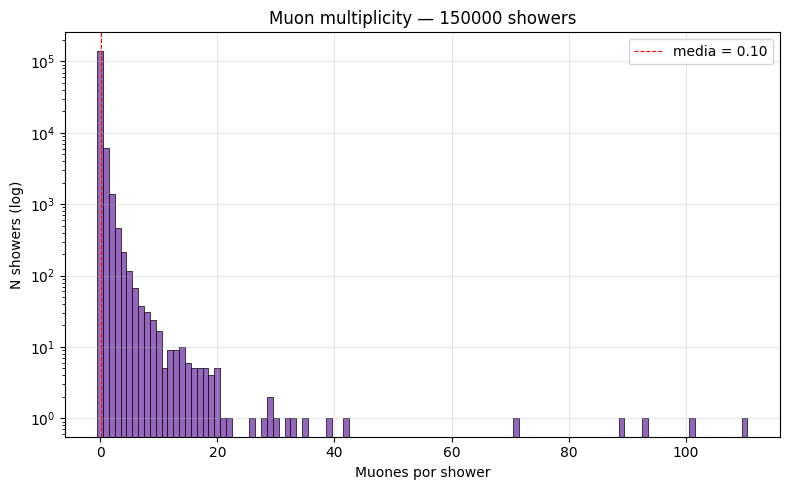

Showers sin muones:         141475 (94.3%)
Showers con ≥10 muones:     97 (0.1%)
Máximo muones en un shower: 110


In [10]:
multiplicity = muons.groupby('event').size()
# Eventos sin muones también cuentan (0). Los rellenamos:
all_events = pd.Series(0, index=range(1, md.n_showers + 1))
all_events.loc[multiplicity.index] = multiplicity.values

fig, ax = plt.subplots(figsize=(8, 5))
max_n = int(all_events.max())
ax.hist(all_events, bins=np.arange(0, max_n + 2) - 0.5, color='tab:purple', edgecolor='k', lw=0.5)
ax.set_yscale('log')
ax.set_xlabel('Muones por shower')
ax.set_ylabel('N showers (log)')
ax.set_title(f'Muon multiplicity — {md.n_showers} showers')
ax.axvline(all_events.mean(), color='red', ls='--', lw=0.8, label=f'media = {all_events.mean():.2f}')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Showers sin muones:         {(all_events == 0).sum()} ({(all_events == 0).mean():.1%})")
print(f"Showers con ≥10 muones:     {(all_events >= 10).sum()} ({(all_events >= 10).mean():.1%})")
print(f"Máximo muones en un shower: {max_n}")

## 2. Espectro de energía

**Qué muestra:** distribución de energías cinéticas de los muones, separados por carga, en escala log-log.

**Por qué importa:** el espectro de muones a nivel del suelo es aproximadamente una ley de potencias dN/dE ∝ E^(-γ) con γ ≈ 3.7 (los muones blandos decaen antes de llegar). Acá hay un cutoff inferior por nuestra `ERANGE` y por las pérdidas atmosféricas.

**Qué buscar:**
- Espectro decreciente, sin saltos ni picos artificiales.
- Cutoff inferior cerca de ~100 MeV (energía mínima para sobrevivir hasta el OBSLEV).

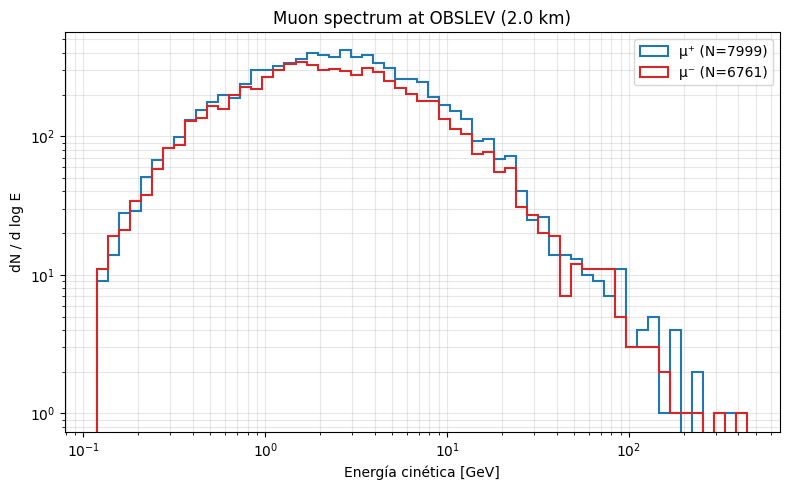

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

bins = np.logspace(np.log10(max(muons['energy_gev'].min(), 1e-3)),
                    np.log10(muons['energy_gev'].max()), 60)
for pid, label, color in [(5, 'μ⁺', 'tab:blue'), (6, 'μ⁻', 'tab:red')]:
    e = muons.loc[muons['particle_id'] == pid, 'energy_gev']
    if len(e):
        ax.hist(e, bins=bins, histtype='step', lw=1.5, label=f'{label} (N={len(e)})', color=color)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Energía cinética [GeV]')
ax.set_ylabel('dN / d log E')
ax.set_title(f'Muon spectrum at OBSLEV ({md.obslev_cm/1e5:.1f} km)')
ax.legend()
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

## 3. Razón de cargas μ⁺/μ⁻ vs energía

**Qué muestra:** el cociente N(μ⁺) / N(μ⁻) por bin de energía.

**Por qué importa:** medición clásica de cosmic rays. La razón μ⁺/μ⁻ refleja la composición de los primarios (más protones que antiprotones → más π⁺ que π⁻ → más μ⁺ que μ⁻).

**Qué buscar:**
- Razón ≈ 1.27 a baja energía (~1–10 GeV).
- Crece a ~1.4 a 100 GeV – 1 TeV.
- Si da ≈ 1.0 → algo mezcló las cargas. Si da > 2 → algo está mal con el spectrum.

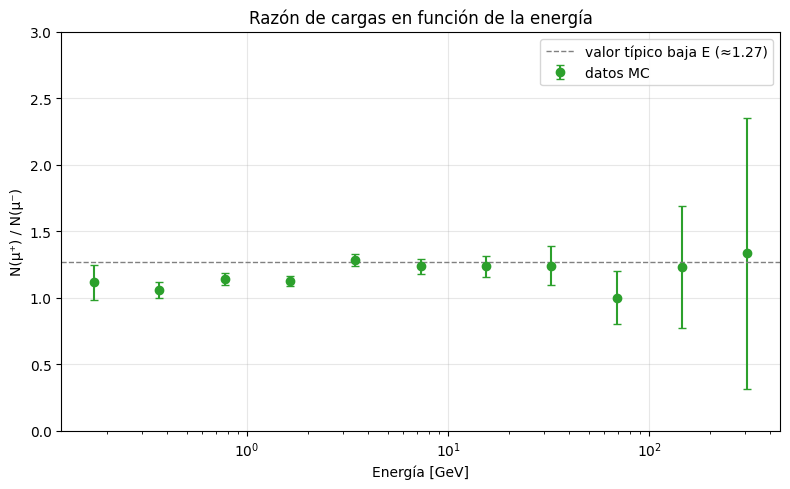

Razón global μ⁺/μ⁻: 1.18


In [12]:
fig, ax = plt.subplots(figsize=(8, 5))

e_bins = np.logspace(np.log10(muons['energy_gev'].min()),
                      np.log10(muons['energy_gev'].max()), 12)
n_plus,  _ = np.histogram(muons.loc[muons['particle_id'] == 5, 'energy_gev'], bins=e_bins)
n_minus, _ = np.histogram(muons.loc[muons['particle_id'] == 6, 'energy_gev'], bins=e_bins)

centers = np.sqrt(e_bins[:-1] * e_bins[1:])
mask = (n_minus > 0) & (n_plus > 0)
ratio = np.where(n_minus > 0, n_plus / np.maximum(n_minus, 1), np.nan)
# Error Poisson: σ(N+/N-) ≈ (N+/N-) * sqrt(1/N+ + 1/N-)
err = np.where(mask, ratio * np.sqrt(1/np.maximum(n_plus, 1) + 1/np.maximum(n_minus, 1)), np.nan)

ax.errorbar(centers[mask], ratio[mask], yerr=err[mask], fmt='o', color='tab:green',
            capsize=3, label='datos MC')
ax.axhline(1.27, color='gray', ls='--', lw=1, label='valor típico baja E (≈1.27)')
ax.set_xscale('log')
ax.set_xlabel('Energía [GeV]')
ax.set_ylabel('N(μ⁺) / N(μ⁻)')
ax.set_title('Razón de cargas en función de la energía')
ax.set_ylim(0, max(3, np.nanmax(ratio) * 1.2))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

ratio_global = (muons['particle_id'] == 5).sum() / max(1, (muons['particle_id'] == 6).sum())
print(f'Razón global μ⁺/μ⁻: {ratio_global:.2f}')

## 4. Ángulo cenital θ

**Qué muestra:** distribución del ángulo entre la dirección del muon y la vertical.

- θ = 0° → muon vertical descendente.
- θ = 90° → muon horizontal.

**Por qué importa:** con `THETAP 0–89°` y *flat detector sampling* (peso ∝ cos θ), la distribución natural da más eventos a θ pequeños (área proyectada del detector). El cenital de los muones que llegan al OBSLEV refleja esa estadística.

**Qué buscar:**
- Pico entre 10° y 30°.
- Cola decreciente hasta ~80–85°.
- **Si todos los muones quedan en una región estrecha (por ej. 100% θ > 70°)

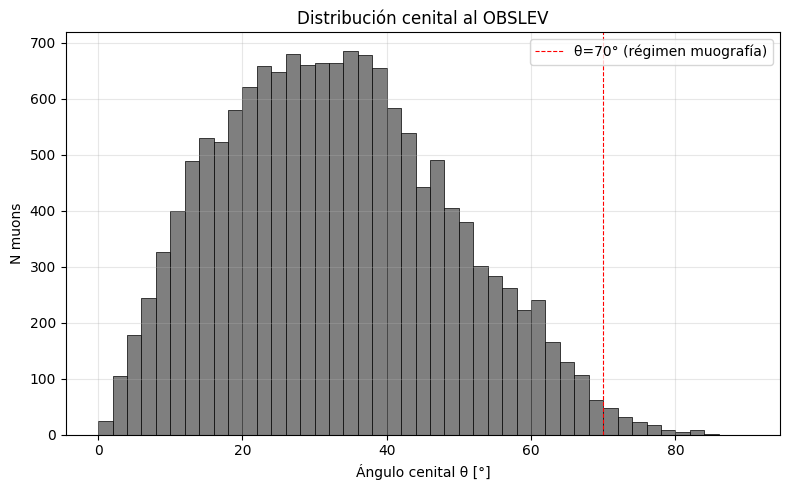

Muones con θ > 70°: 142 (1.0%) — relevantes para muografía lateral


In [13]:
fig, ax = plt.subplots(figsize=(8, 5))

theta_deg = np.degrees(muons['theta_rad'])
ax.hist(theta_deg, bins=np.linspace(0, 90, 46), color='tab:gray', edgecolor='k', lw=0.5)
ax.set_xlabel('Ángulo cenital θ [°]')
ax.set_ylabel('N muons')
ax.set_title('Distribución cenital al OBSLEV')
ax.grid(alpha=0.3)
ax.axvline(70, color='red', ls='--', lw=0.8, label='θ=70° (régimen muografía)')
ax.legend()
plt.tight_layout()
plt.show()

n_horiz = (theta_deg > 70).sum()
print(f'Muones con θ > 70°: {n_horiz} ({n_horiz/len(muons):.1%}) — relevantes para muografía lateral')

## 5. Ángulo azimutal φ

**Qué muestra:** dirección azimutal (rotación alrededor del eje vertical), en coordenadas polares.

**Por qué importa:** simulamos `PHIP 0–360°` isotrópico, así que la distribución debe ser **uniforme**. Cualquier asimetría revela algo: ruido estadístico (con pocos eventos), o efecto del campo geomagnético sobre las partículas cargadas (a baja energía los muones se desvían east-west).

**Qué buscar:**
- Histograma sin picos notables — sólo fluctuaciones de Poisson.
- Con campo geomagnético on, una leve asimetría este-oeste a baja E es esperable, pero pequeña.

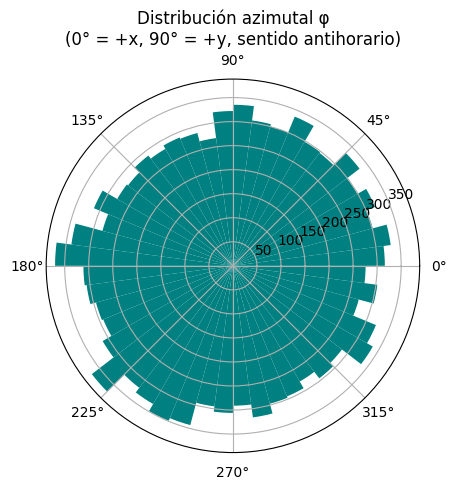

In [14]:
fig, ax = plt.subplots(figsize=(8, 5), subplot_kw={'projection': 'polar'})

phi = muons['phi_rad'].to_numpy()
ax.hist(phi, bins=np.linspace(-np.pi, np.pi, 49), color='teal')
ax.set_title('Distribución azimutal φ\n(0° = +x, 90° = +y, sentido antihorario)')
ax.set_theta_zero_location('E')
ax.set_theta_direction(1)
plt.tight_layout()
plt.show()

## 6. Mapa 2D θ–φ

**Qué muestra:** densidad de muones en el plano (φ, θ). Es la información angular completa.

**Por qué importa:** para muografía vamos a *recortar* este mapa a la dirección donde está el volcán visto desde el detector. Los píxeles dentro del recorte son los muones cuyos rayos atravesarían el cuerpo del volcán.

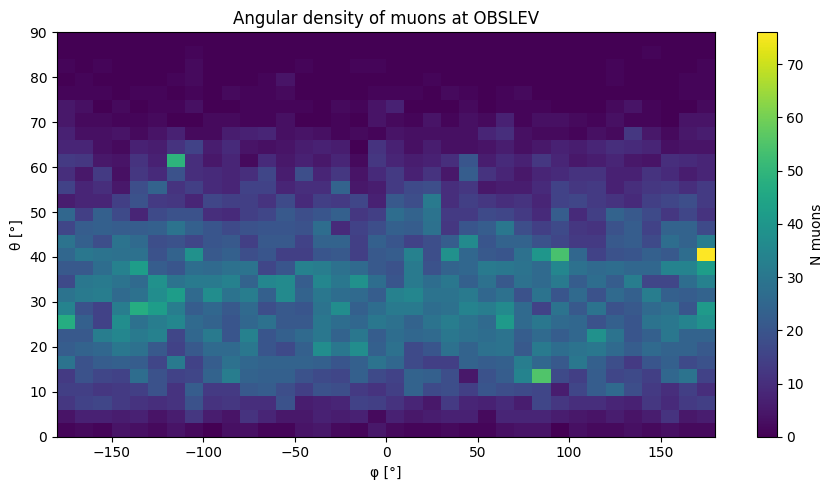

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))

h, xe, ye, im = ax.hist2d(
    np.degrees(muons['phi_rad']),
    np.degrees(muons['theta_rad']),
    bins=[36, 30],
    range=[[-180, 180], [0, 90]],
    cmap='viridis',
)
ax.set_xlabel('φ [°]')
ax.set_ylabel('θ [°]')
ax.set_title('Angular density of muons at OBSLEV')
plt.colorbar(im, ax=ax, label='N muons')
plt.tight_layout()
plt.show()

## 7. Energía vs ángulo cenital — *el plot más relevante para muografía*

**Qué muestra:** energía del muon vs su ángulo cenital — scatter individual y la mediana por bin de θ.

**Por qué importa:** los muones que llegan al OBSLEV con θ grande tuvieron que atravesar **mucha más atmósfera** (el camino crece como sec θ). Solo sobreviven los muy energéticos — los blandos se absorben. Por eso esperamos:

$$\langle E_\mu \rangle (\theta) \sim 1 / \cos\theta$$

Esto es **clave para muografía**: los muones que cruzarán el volcán lateralmente son justamente los más energéticos, y por eso penetran kilómetros de roca densa.

**Qué buscar:**
- Correlación clara: a mayor θ, mayor energía mediana.
- El piso (mínima energía sobreviviente) sube con θ.

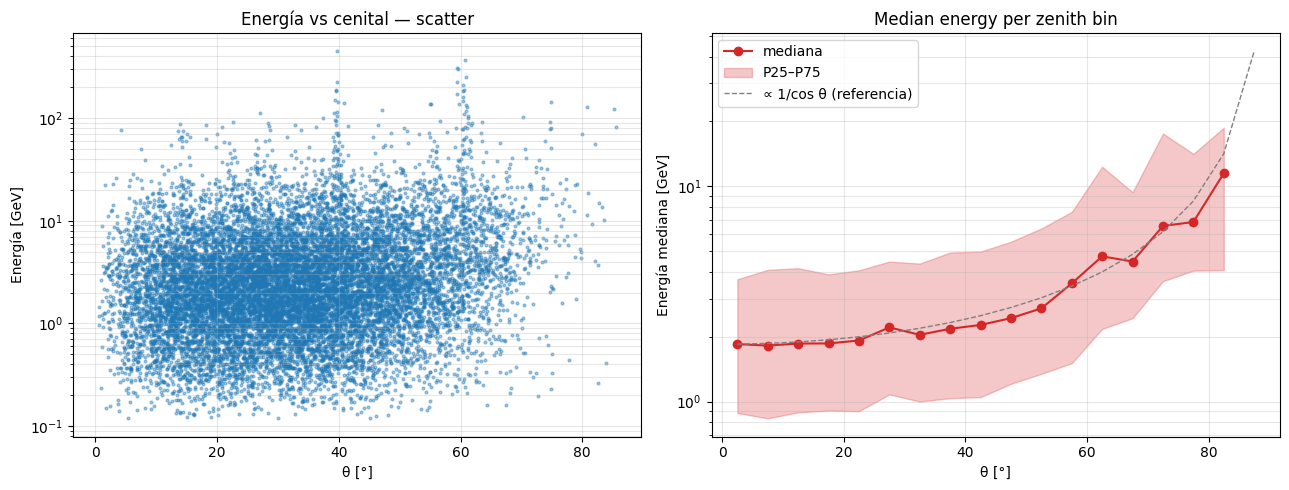

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel A: scatter individual
axes[0].scatter(theta_deg, muons['energy_gev'], s=4, alpha=0.4, color='tab:blue')
axes[0].set_yscale('log')
axes[0].set_xlabel('θ [°]')
axes[0].set_ylabel('Energía [GeV]')
axes[0].set_title('Energía vs cenital — scatter')
axes[0].grid(alpha=0.3, which='both')

# Panel B: mediana por bin de θ + banda P25–P75
theta_bins = np.linspace(0, 90, 19)
bin_centers = 0.5 * (theta_bins[:-1] + theta_bins[1:])
median_e, p25, p75 = [], [], []
for lo, hi in zip(theta_bins[:-1], theta_bins[1:]):
    sel = muons.loc[(theta_deg >= lo) & (theta_deg < hi), 'energy_gev']
    if len(sel) >= 3:
        median_e.append(sel.median()); p25.append(sel.quantile(0.25)); p75.append(sel.quantile(0.75))
    else:
        median_e.append(np.nan); p25.append(np.nan); p75.append(np.nan)
median_e, p25, p75 = map(np.array, (median_e, p25, p75))

axes[1].plot(bin_centers, median_e, 'o-', color='tab:red', label='mediana')
axes[1].fill_between(bin_centers, p25, p75, alpha=0.25, color='tab:red', label='P25–P75')
# Linea de referencia 1/cos(θ) escalada al primer bin con datos
first_valid = int(np.argmax(~np.isnan(median_e)))
if not np.isnan(median_e[first_valid]):
    cos_curve = median_e[first_valid] * np.cos(np.radians(bin_centers[first_valid])) / np.cos(np.radians(bin_centers))
    axes[1].plot(bin_centers, cos_curve, '--', color='gray', lw=1, label='∝ 1/cos θ (referencia)')
axes[1].set_yscale('log')
axes[1].set_xlabel('θ [°]')
axes[1].set_ylabel('Energía mediana [GeV]')
axes[1].set_title('Median energy per zenith bin')
axes[1].legend()
axes[1].grid(alpha=0.3, which='both')

plt.tight_layout()
plt.show()

## 8. Posición de impacto (x, y)

**Qué muestra:** dónde aterriza cada muon en el plano horizontal del OBSLEV. El origen (0, 0) es el punto donde el primer primario entró a la atmósfera.

**Por qué importa:** la cascada se *abre* lateralmente conforme se desarrolla. Showers casi verticales aterrizan en un círculo pequeño; showers oblicuos producen *footprints* alargados que pueden extenderse decenas de kilómetros.

Panel derecho: **densidad lateral** (muones por m²). Es la función LDF (lateral density function), usada típicamente en arrays de rayos cósmicos.

**Qué buscar:**
- Scatter con pico cerca del origen y cola radial.
- LDF decreciente con r — típicamente como ley de potencias.
- Si las posiciones tienen un patrón regular (cuadrícula, líneas) → bug en muestreo.

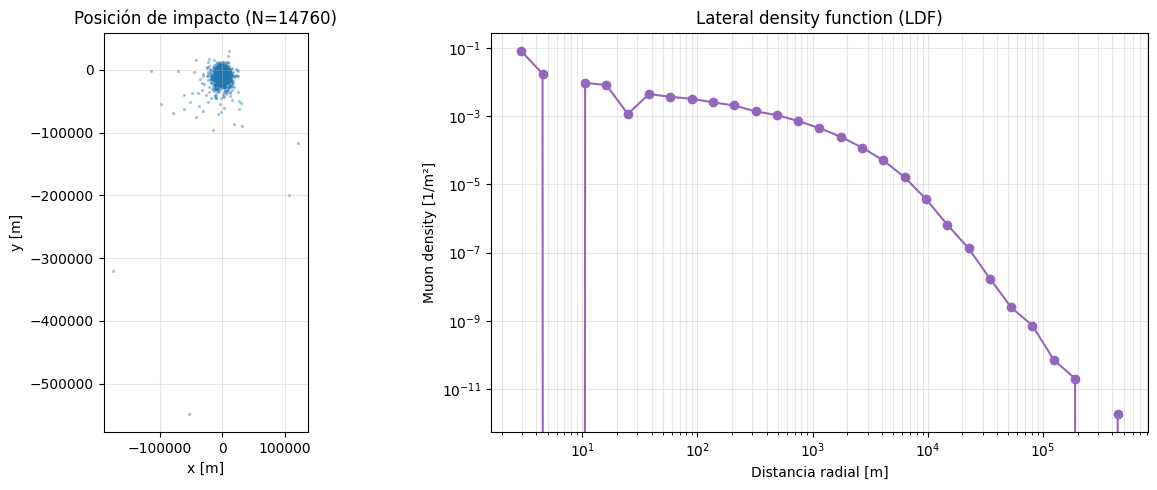

Radio mediano: 2521.8 m, P95: 11432 m, máximo: 550796 m


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel A: scatter (x, y)
x_m = muons['x_cm'].to_numpy() / 100
y_m = muons['y_cm'].to_numpy() / 100
axes[0].scatter(x_m, y_m, s=2, alpha=0.3, color='tab:blue')
axes[0].set_xlabel('x [m]')
axes[0].set_ylabel('y [m]')
axes[0].set_title(f'Posición de impacto (N={len(muons)})')
axes[0].set_aspect('equal')
axes[0].grid(alpha=0.3)

# Panel B: histograma radial (densidad de área)
r_m = np.sqrt(x_m**2 + y_m**2)
r_bins = np.logspace(np.log10(max(r_m.min(), 1)), np.log10(r_m.max()), 30)
counts, edges = np.histogram(r_m, bins=r_bins)
annulus_area = np.pi * (edges[1:]**2 - edges[:-1]**2)
density = counts / np.maximum(annulus_area, 1)
r_centers = np.sqrt(edges[:-1] * edges[1:])
axes[1].plot(r_centers, density, 'o-', color='tab:purple')
axes[1].set_xscale('log'); axes[1].set_yscale('log')
axes[1].set_xlabel('Distancia radial [m]')
axes[1].set_ylabel('Muon density [1/m²]')
axes[1].set_title('Lateral density function (LDF)')
axes[1].grid(alpha=0.3, which='both')

plt.tight_layout()
plt.show()

print(f'Radio mediano: {np.median(r_m):.1f} m, P95: {np.percentile(r_m, 95):.0f} m, máximo: {r_m.max():.0f} m')

## 9. Perfil longitudinal — cómo nace y muere la cascada

Hasta acá miramos *solo* los muones que llegan al OBSLEV. Esta sección abre la caja: mira **toda la cascada** mientras se desarrolla en la atmósfera, gracias al archivo `.long` que CORSIKA genera cuando `LONGI T` está activado.

**Qué es la profundidad atmosférica X.** Es la masa de aire por unidad de área que el shower ha atravesado (g/cm²). Es más útil que la altura en metros porque las interacciones dependen de cuánta materia atravesó la partícula, no de la altitud geométrica. Algunos valores de referencia:

| Lugar | X vertical (g/cm²) |
|---|---|
| Tope de atmósfera | 0 |
| Altitud crucero avión (~10 km) | ~260 |
| Cima Fuego (3.76 km) | ~660 |
| Nivel del mar | ~1030 |

**Qué muestra el plot.** Para cada paso de X, CORSIKA cuenta cuántas partículas de cada tipo están presentes en ese instante en la cascada — es el "censo" de la cascada conforme se desarrolla.

**El pico se llama X_max.** Es la profundidad donde la cascada alcanza su tamaño máximo. La gran observación clásica: **e⁺/e⁻ y fotones explotan y mueren rápido** (perfil tipo Gaisser–Hillas, X_max cerca de 600–700 g/cm² para primarios de 100 GeV), mientras los **muones, una vez creados, casi no se atenúan** (su perfil se estabiliza, casi plano hasta el suelo).

⚠️ **Nota:** Para que esta sección funcione necesitamos el archivo `.long`. La corrida de **producción (1101) lo tiene desactivado** (`LONGI F`) para no inflar el log; usamos la corrida **test (1001)** acá. Esto es a propósito — el perfil promedio no requiere 50,000 showers, con 500 ya se ve la física.

In [18]:
# RUNNR de la corrida con LONGI activado (perfil longitudinal). Solo las
# corridas de TEST tienen LONGI=T en su steering y por lo tanto generan
# archivo .long. Las de produccion lo desactivan por tamano de log.
# Si DAT<RUNNR_LONG>.long no existe localmente, se intenta auto-detectar
# el primer .long disponible en sim/output/.
RUNNR_LONG = 1001

run_long = CorsikaRun(REPO_ROOT / "sim" / "output", run_number=RUNNR_LONG)
if not run_long.has_long:
    avail = sorted((REPO_ROOT / "sim" / "output").glob("DAT*.long"))
    if not avail:
        raise RuntimeError(
            f"No se encontro DAT{RUNNR_LONG:06d}.long ni ningun otro .long "
            f"en sim/output/. Para generarlo corre `make test-corsika` "
            f"(~8 min): produce DAT001001.long via fuego_test.inp que tiene "
            f"LONGI=T. Las corridas de produccion no generan .long."
        )
    found = int(avail[0].stem.replace("DAT", ""))
    print(f"DAT{RUNNR_LONG:06d}.long no existe; usando DAT{found:06d}.long de fallback.")
    run_long = CorsikaRun(REPO_ROOT / "sim" / "output", run_number=found)

long_df = run_long.long.particles()
md_long = run_long.lst.metadata()
n_showers_long = long_df['shower'].nunique()
print(f"Showers con perfil: {n_showers_long}")
print(f"Pasos de profundidad por shower: {(long_df['shower'] == long_df['shower'].iloc[0]).sum()}")
print(f"Rango X: {long_df['depth'].min():.0f} - {long_df['depth'].max():.0f} g/cm2")
long_df.head(3)

Showers con perfil: 500
Pasos de profundidad por shower: 41
Rango X: 20 - 820 g/cm2


,shower,depth,gammas,positrons,electrons,mu+,mu-,hadrons,charged,nuclei,cherenkov
0,1,20.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
1,1,40.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
2,1,60.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0


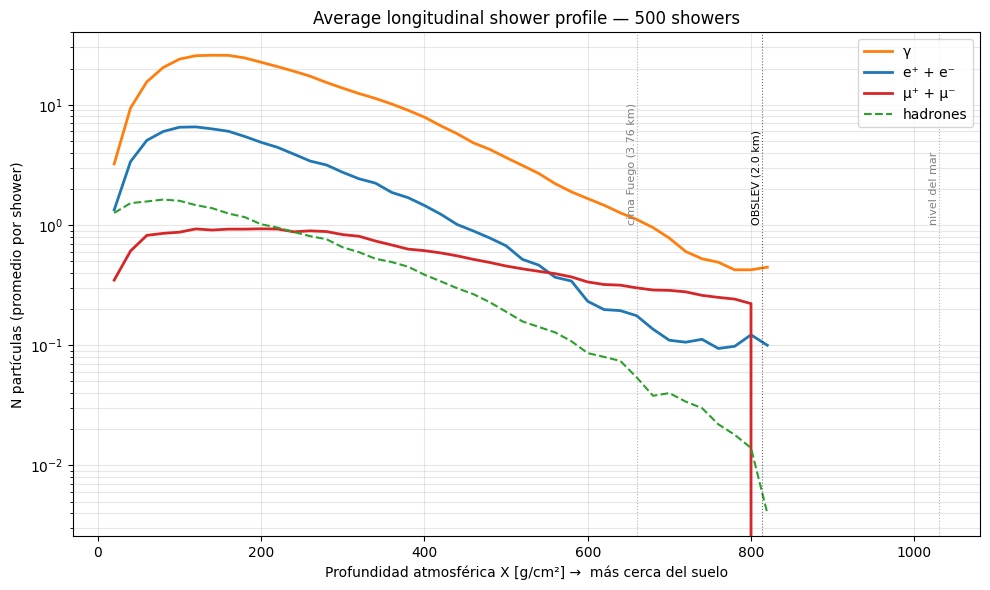

In [19]:
# Promedio del perfil sobre todos los showers, por componente.
# Resultado: cuántas partículas de cada tipo "viven" a profundidad X en un shower típico.
profile = long_df.groupby('depth')[['gammas', 'positrons', 'electrons', 'mu+', 'mu-', 'hadrons']].mean()
profile['e±'] = profile['positrons'] + profile['electrons']
profile['μ±'] = profile['mu+'] + profile['mu-']

# Profundidad vertical (g/cm²) en algunos sitios clave, para anotaciones:
X_OBSLEV = md_long.obslev_gcm2 or 813.3      # OBSLEV del steering (Fuego, 2 km)
X_FUEGO_CIMA  = 660                          # estimado a 3.76 km
X_SEA_LEVEL   = 1030

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(profile.index, profile['gammas'],  label='γ',        color='tab:orange', lw=2)
ax.plot(profile.index, profile['e±'],      label='e⁺ + e⁻',  color='tab:blue',   lw=2)
ax.plot(profile.index, profile['μ±'],      label='μ⁺ + μ⁻',  color='tab:red',    lw=2)
ax.plot(profile.index, profile['hadrons'], label='hadrones', color='tab:green',  lw=1.5, ls='--')

# Líneas de referencia
for X, label, color in [
    (X_FUEGO_CIMA, 'cima Fuego (3.76 km)', 'gray'),
    (X_OBSLEV,     f'OBSLEV ({md_long.obslev_cm/1e5:.1f} km)', 'black'),
    (X_SEA_LEVEL,  'nivel del mar',         'gray'),
]:
    ax.axvline(X, color=color, ls=':', lw=0.8, alpha=0.6)
    ax.text(X, ax.get_ylim()[1] if False else 1, label, rotation=90,
            va='bottom', ha='right', fontsize=8, color=color)

ax.set_yscale('log')
ax.set_xlabel('Profundidad atmosférica X [g/cm²] →  más cerca del suelo')
ax.set_ylabel('N partículas (promedio por shower)')
ax.set_title(f'Average longitudinal shower profile — {n_showers_long} showers')
ax.legend(loc='upper right')
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

### X_max y N_max — los dos números clásicos del perfil

Dos cantidades resumen el perfil de cada shower:

- **X_max:** profundidad atmosférica donde la componente electromagnética (e⁺ + e⁻ + γ, o solo e±) alcanza su número máximo. Físicamente: la cascada se está "abriendo" y al mismo tiempo perdiendo energía por ionización; X_max es el equilibrio entre ambos.
- **N_max:** número de partículas en ese máximo.

**Por qué importa para esta tesis:**
- X_max **depende del primario** (la fórmula heurística: protón → X_max más profundo; hierro → X_max más superficial). En experimentos reales se usa como discriminador de composición.
- **Para muografía** lo crítico no es X_max sino **dónde nacen y dónde mueren los muones**. Mira en el plot anterior: la curva μ± sube hasta ~600 g/cm² y después se mantiene prácticamente plana. *Eso* es lo que hace posible la muografía: el flujo de muones a la cima del Fuego (X ≈ 660) es esencialmente el mismo que al nivel del mar (X ≈ 1030).

El gráfico abajo muestra la **distribución de X_max** sobre los 500 showers — cuánto fluctúa de evento a evento.

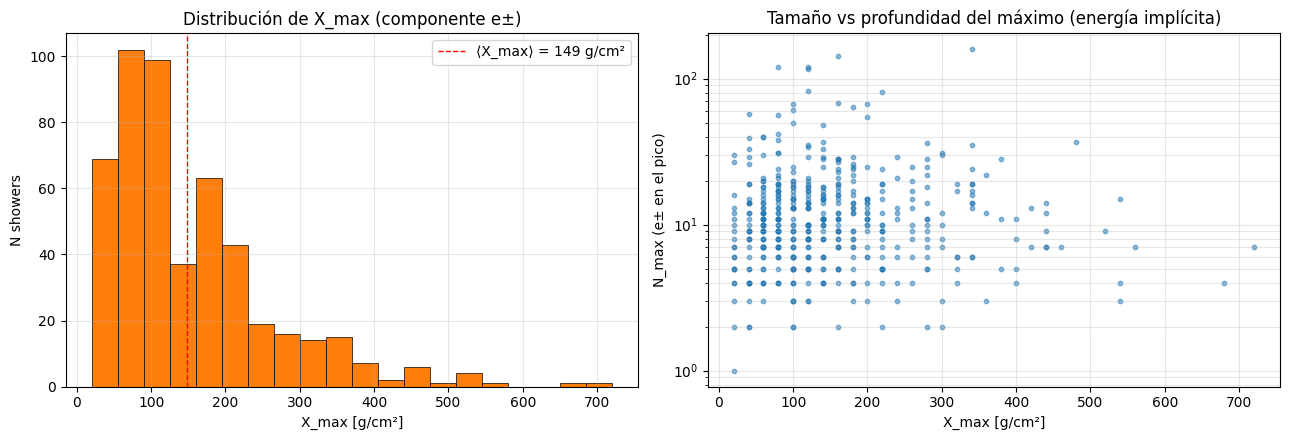

⟨X_max⟩          = 149 ± 109 g/cm²
⟨N_max⟩ (e±)     = 14.1  (mediana = 10.0)
Al OBSLEV (813 g/cm²):
   ⟨N μ±⟩ = 0.22,  ⟨N e±⟩ = 0.12   →   μ/e ≈ 1.82

Lecturas físicas:
• X_max bajo (~150) vs el 'libro de texto' (~600 g/cm² @ 100 GeV) refleja
  que con espectro E^-2.7 la mayoría de showers son de E~10–30 GeV — cascadas
  pequeñas, que alcanzan su máximo muy arriba en la atmósfera.
• μ/e > 1 al suelo: la componente EM se atenúa más rápido que la muónica.
  Por eso a nivel del mar los muones DOMINAN en número entre las cargadas,
  aunque al nacer (en el shower) sean una fracción pequeña.


In [20]:
# X_max y N_max por shower, usando la componente e± como referencia (estándar).
charged_em = long_df.assign(e_pm=long_df['positrons'] + long_df['electrons'])
idx_max = charged_em.groupby('shower')['e_pm'].idxmax()
xmax_per_shower = charged_em.loc[idx_max, ['shower', 'depth', 'e_pm']].rename(
    columns={'depth': 'X_max', 'e_pm': 'N_max'}
)

# Conteo de partículas cerca del OBSLEV (paso más profundo que aún esté
# por encima del observation level — CORSIKA registra algunos pasos más allá
# por la curvatura/extensión vertical, pero esos ya no son "el suelo").
near_obslev = (long_df[long_df['depth'] <= md_long.obslev_gcm2]
               .sort_values('depth').groupby('shower').tail(1))
mu_at_ground = (near_obslev['mu+'] + near_obslev['mu-']).mean()
em_at_ground = (near_obslev['positrons'] + near_obslev['electrons']).mean()
mu_over_em   = mu_at_ground / max(em_at_ground, 1e-9)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Panel A: histograma X_max
axes[0].hist(xmax_per_shower['X_max'], bins=20, color='tab:orange', edgecolor='k', lw=0.5)
axes[0].axvline(xmax_per_shower['X_max'].mean(), color='red', ls='--', lw=1,
                label=f'⟨X_max⟩ = {xmax_per_shower["X_max"].mean():.0f} g/cm²')
axes[0].set_xlabel('X_max [g/cm²]')
axes[0].set_ylabel('N showers')
axes[0].set_title('Distribución de X_max (componente e±)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Panel B: N_max vs X_max — eventos más energéticos llegan más profundo y son más grandes.
axes[1].scatter(xmax_per_shower['X_max'], xmax_per_shower['N_max'],
                s=10, alpha=0.5, color='tab:blue')
axes[1].set_yscale('log')
axes[1].set_xlabel('X_max [g/cm²]')
axes[1].set_ylabel('N_max (e± en el pico)')
axes[1].set_title('Tamaño vs profundidad del máximo (energía implícita)')
axes[1].grid(alpha=0.3, which='both')

plt.tight_layout()
plt.show()

print(f"⟨X_max⟩          = {xmax_per_shower['X_max'].mean():.0f} ± {xmax_per_shower['X_max'].std():.0f} g/cm²")
print(f"⟨N_max⟩ (e±)     = {xmax_per_shower['N_max'].mean():.1f}  (mediana = {xmax_per_shower['N_max'].median():.1f})")
print(f"Al OBSLEV ({md_long.obslev_gcm2:.0f} g/cm²):")
print(f"   ⟨N μ±⟩ = {mu_at_ground:.2f},  ⟨N e±⟩ = {em_at_ground:.2f}   →   μ/e ≈ {mu_over_em:.2f}")
print()
print("Lecturas físicas:")
print("• X_max bajo (~150) vs el 'libro de texto' (~600 g/cm² @ 100 GeV) refleja")
print("  que con espectro E^-2.7 la mayoría de showers son de E~10–30 GeV — cascadas")
print("  pequeñas, que alcanzan su máximo muy arriba en la atmósfera.")
print("• μ/e > 1 al suelo: la componente EM se atenúa más rápido que la muónica.")
print("  Por eso a nivel del mar los muones DOMINAN en número entre las cargadas,")
print("  aunque al nacer (en el shower) sean una fracción pequeña.")

## Convergencia: ¿cuántos showers son suficientes para la tesis?

La estadística de un Monte Carlo escala como $1/\sqrt{N}$: con $N$ eventos en un bin, el error relativo del conteo es $1/\sqrt{N}$. Para muografía no nos importa la estadística global — nos importa **la del bin más castigado**, que es el de muones inclinados ($\theta > 70°$). Esos son los que cruzan el volcán lateralmente y los que tenemos que contar bien.

**Lo que vamos a hacer:**
1. Cargar todos los runs de tamaño variable que tenemos en `sim/output/`.
2. Para cada uno calcular: muones totales, muones con $\theta>70°$, mediana de momento, razón $\mu^+/\mu^-$.
3. Graficar el error relativo $1/\sqrt{N(\theta>70°)}$ vs NSHOW, y la **estabilidad** de las medianas a medida que crece la estadística.

**Qué buscar:** dónde el error relativo en el bin crítico baja a un valor tolerable (~10%) y las medianas dejan de moverse fuera de su barra de error. Ese punto define el NSHOW mínimo para la corrida final del estudio.


In [ ]:
from corsikaio import CorsikaParticleFile
import warnings
warnings.filterwarnings('ignore', message='CORSIKA version')

OUTPUT_DIR = REPO_ROOT / 'sim' / 'output'

# Descubre todos los DAT del directorio, lee NSHOW del run_header (no del .lst,
# que se sobrescribe entre runs paramétricos), y para cada uno carga los muones.
summary_rows = []
muon_dfs = {}

for dat_path in sorted(OUTPUT_DIR.glob('DAT[0-9]*')):
    if dat_path.suffix:  # ignorar .long
        continue
    with CorsikaParticleFile(str(dat_path)) as f:
        nshow = int(f.run_header['n_showers'])
        runnr = int(f.run_header['run_number'])
    sub_run = CorsikaRun(OUTPUT_DIR, run_number=runnr)
    mu = sub_run.particles.muons()
    if mu.empty:
        continue
    mu['theta_deg'] = np.degrees(mu['theta_rad'])
    mu['p_gevc'] = np.sqrt(mu['px']**2 + mu['py']**2 + mu['pz']**2)
    muon_dfs[nshow] = mu

    n_mu = len(mu)
    n_horiz = (mu['theta_deg'] > 70).sum()
    n_plus  = (mu['particle_id'] == 5).sum()
    n_minus = (mu['particle_id'] == 6).sum()
    summary_rows.append({
        'RUNNR': runnr,
        'NSHOW': nshow,
        'N_muones': n_mu,
        'mu_por_shower': n_mu / nshow,
        'N_theta_gt70': n_horiz,
        'frac_theta_gt70': n_horiz / n_mu if n_mu else 0,
        'err_rel_horiz_%': 100 / np.sqrt(n_horiz) if n_horiz > 0 else np.nan,
        'p_mediana_GeV': mu['p_gevc'].median(),
        'mu+/mu-': n_plus / max(n_minus, 1),
    })

summary = pd.DataFrame(summary_rows).sort_values('NSHOW').reset_index(drop=True)
summary.style.format({
    'mu_por_shower': '{:.4f}',
    'frac_theta_gt70': '{:.2%}',
    'err_rel_horiz_%': '{:.1f}',
    'p_mediana_GeV': '{:.3f}',
    'mu+/mu-': '{:.3f}',
})


### Plot 1 — Error estadístico vs NSHOW

Tres líneas:
- **muones totales**: error en el conteo global, $1/\sqrt{N_\mu}$.
- **muones θ>70°**: error en el bin de muografía. Más alto porque hay menos eventos ahí.
- **referencia $1/\sqrt{N_\mathrm{showers}}$**: lo que esperaríamos si cada shower produjera *exactamente* un muon. La separación entre esta y las otras dos cuenta cuántos muones útiles produce cada shower.

Un criterio razonable para muografía: error relativo $\le 10\%$ en el bin $\theta > 70°$ (línea roja en el plot). Es donde las curvas cruzan la guía horizontal.


In [ ]:
fig, ax = plt.subplots(figsize=(9, 5.5))

n = summary['NSHOW'].to_numpy()
ax.plot(n, 100/np.sqrt(summary['N_muones']),       'o-', color='tab:blue',
        label='total muon error')
ax.plot(n, summary['err_rel_horiz_%'],             's-', color='tab:red',
        label='muon error θ>70° (critical bin)')
ax.plot(n, 100/np.sqrt(n),                          '--', color='gray', alpha=0.7,
        label='referencia 1/√N_showers')

ax.axhline(10, color='red', ls=':', lw=1, alpha=0.7)
ax.text(n.min(), 10.5, '10% (criterio muografía)', color='red', fontsize=9)
ax.axhline(5,  color='red', ls=':', lw=0.7, alpha=0.5)
ax.text(n.min(), 5.2,  '5%', color='red', fontsize=9, alpha=0.7)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('NSHOW (simulated showers)')
ax.set_ylabel('error relativo estadístico [%]')
ax.set_title('Convergencia estadística vs tamaño del run')
ax.grid(alpha=0.3, which='both')
ax.legend()
plt.tight_layout()
plt.show()


### Plot 2 — Estabilidad de medianas

El error de Poisson supone que cada bin es independiente. Lo que **no** captura es el sesgo: si el espectro o la angular del MC todavía no está bien muestreado, las medianas de momento y θ van a deambular con NSHOW antes de estabilizarse. Si el run final está en el régimen estable, todos los puntos a NSHOW grandes caen dentro de una banda angosta compatible con el run más grande.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for ax, col, ylabel, ref_color in [
    (axes[0], 'p_mediana_GeV', 'mediana |p| [GeV/c]',  'tab:blue'),
    (axes[1], 'mu+/mu-',        'razón μ⁺/μ⁻',          'tab:green'),
    (axes[2], 'frac_theta_gt70', 'fracción θ>70°',      'tab:purple'),
]:
    y = summary[col].to_numpy()
    # Barra de error Poisson aproximada en el cociente o la mediana
    rel_err = 1 / np.sqrt(summary['N_muones'].to_numpy())
    ax.errorbar(summary['NSHOW'], y, yerr=np.abs(y)*rel_err,
                fmt='o-', color=ref_color, capsize=3)
    # Línea de referencia: valor del run más grande
    big = summary.iloc[summary['NSHOW'].idxmax()]
    ax.axhline(big[col], color='red', ls='--', lw=0.8, alpha=0.7,
               label=f'NSHOW={int(big["NSHOW"]):,} (ref.)')
    ax.set_xscale('log')
    ax.set_xlabel('NSHOW')
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)
    ax.legend(loc='best', fontsize=9)

fig.suptitle('Estabilidad de observables clave vs NSHOW')
plt.tight_layout()
plt.show()


### Recomendación de NSHOW para el estudio final

La celda siguiente toma los datos cargados y reporta dos cosas:

1. El NSHOW empírico donde el error en $\theta>70°$ cruza el 10% y el 5%.
2. El NSHOW **extrapolado** para llegar a esos umbrales suponiendo escalamiento $1/\sqrt{N}$   (usando la tasa observada $N_{\theta>70°}/\mathrm{NSHOW}$ promedio).


In [ ]:
# Tasa promedio de muones útiles por shower (los runs grandes son los que mejor la estiman)
big_run = summary.iloc[summary['NSHOW'].idxmax()]
rate_horiz = big_run['N_theta_gt70'] / big_run['NSHOW']

# Para error relativo objetivo e, hace falta N_eventos = (100/e)^2 ⇒ NSHOW = N/rate
def nshow_for_error(target_pct: float) -> int:
    n_needed = (100 / target_pct) ** 2
    return int(np.ceil(n_needed / rate_horiz))

print(f'Tasa de muones con θ>70°: {rate_horiz:.4f} muones/shower '
      f'(de run NSHOW={int(big_run["NSHOW"]):,})')
print()
print('NSHOW recomendado para alcanzar error relativo objetivo en el bin θ>70°:')
for tgt in [20, 10, 5, 2]:
    n_req = nshow_for_error(tgt)
    print(f'  error ≤ {tgt:>2}% → NSHOW ≈ {n_req:>10,}')

# Cruces empíricos en los datos actuales
crossings = summary[summary['err_rel_horiz_%'] <= 10]
if len(crossings):
    print(f'\nEmpíricamente, error 10% se alcanza desde NSHOW = '
          f'{int(crossings.iloc[0]["NSHOW"]):,} (run {int(crossings.iloc[0]["RUNNR"])}).')
else:
    print('\nNinguna corrida actual baja del 10% en el bin θ>70°; subir NSHOW.')


### Comparación visual entre runs

La gráfica de error es abstracta. Para *ver* la convergencia, superponemos el espectro de momentos $|p|$ para varios NSHOW: a $N$ chico el histograma es **ruidoso, con dientes**; a $N$ grande es **suave**. El run más grande funciona como **referencia visual** (aproximación a la distribución 'verdadera').


In [ ]:
# Reusamos muon_dfs cargados en la sección anterior. Si esta celda se corre suelta:
if 'muon_dfs' not in dir():
    raise RuntimeError('correr antes la celda "### Plot 1 — Error estadístico vs NSHOW"')

# Elegimos un subconjunto representativo: pocos, medio, muchos
available_nshows = sorted(muon_dfs.keys())
# tomamos N=100, ~1k, ~10k y el más grande disponible
def closest(target):
    return min(available_nshows, key=lambda n: abs(n - target))
picks = sorted({closest(100), closest(1000), closest(10000), max(available_nshows)})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(picks)))

# Panel A: PDF de momento (log-log)
p_bins = np.logspace(-1, 3, 60)
for color, nshow in zip(colors, picks):
    p = muon_dfs[nshow]['p_gevc'].to_numpy()
    axes[0].hist(p, bins=p_bins, histtype='step', lw=1.8, density=True,
                 label=f'NSHOW = {nshow:,} (n={len(p):,})', color=color)
axes[0].set_xscale('log'); axes[0].set_yscale('log')
axes[0].set_xlabel('momento |p| [GeV/c]')
axes[0].set_ylabel('PDF normalizada')
axes[0].set_title('Espectro de momentos — superposición a varios NSHOW')
axes[0].grid(alpha=0.3, which='both')
axes[0].legend(fontsize=9)

# Panel B: PDF de ángulo cenital (lineal)
theta_bins = np.linspace(0, 90, 46)
for color, nshow in zip(colors, picks):
    th = muon_dfs[nshow]['theta_deg'].to_numpy()
    axes[1].hist(th, bins=theta_bins, histtype='step', lw=1.8, density=True,
                 label=f'NSHOW = {nshow:,}', color=color)
axes[1].axvline(70, color='red', ls=':', lw=0.8, alpha=0.7,
                label='θ=70° (bin muografía)')
axes[1].set_xlabel('ángulo cenital θ [°]')
axes[1].set_ylabel('PDF normalizada')
axes[1].set_title('Distribución cenital — superposición a varios NSHOW')
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()


### Métrica cuantitativa: Kolmogorov-Smirnov vs el run más grande

La superposición visual da intuición pero no responde *cuántas* cascadas son suficientes. Para eso usamos el **test de Kolmogorov-Smirnov**: la distancia $D$ entre dos distribuciones empíricas es la máxima separación vertical entre sus CDFs:

$$ D_N = \sup_{x} |F_N(x) - F_\infty(x)| $$

$D$ vive en $[0, 1]$. Para muestras del mismo proceso, $D_N \sim 1/\sqrt{N}$ asintóticamente. Tomamos el **run más grande como aproximación de $F_\infty$** y graficamos $D$ vs NSHOW para los demás.

**Criterio de parada**: cuando $D$ del observable crítico (momento de muones con $\theta > 70°$) baja del 5% — equivalentemente, las distribuciones difieren en menos de eso en cualquier punto.


In [ ]:
from scipy.stats import ks_2samp

# Usar el run más grande como pseudo-verdad
ref_nshow = max(available_nshows)
ref_p = muon_dfs[ref_nshow]['p_gevc'].to_numpy()
ref_theta = muon_dfs[ref_nshow]['theta_deg'].to_numpy()
ref_p_horiz = muon_dfs[ref_nshow].query('theta_deg > 70')['p_gevc'].to_numpy()

ks_rows = []
for nshow, mu in muon_dfs.items():
    if nshow == ref_nshow:
        continue
    horiz = mu.query('theta_deg > 70')['p_gevc'].to_numpy()
    ks_p,     _ = ks_2samp(mu['p_gevc'].to_numpy(),   ref_p)
    ks_theta, _ = ks_2samp(mu['theta_deg'].to_numpy(), ref_theta)
    ks_h,     _ = ks_2samp(horiz, ref_p_horiz) if len(horiz) > 5 else (np.nan, None)
    ks_rows.append({
        'NSHOW': nshow, 'n_muones': len(mu), 'n_horiz': len(horiz),
        'KS(p)': ks_p, 'KS(θ)': ks_theta, 'KS(p|θ>70°)': ks_h,
    })
ks_df = pd.DataFrame(ks_rows).sort_values('NSHOW').reset_index(drop=True)
ks_df.style.format({'KS(p)': '{:.3f}', 'KS(θ)': '{:.3f}', 'KS(p|θ>70°)': '{:.3f}'})


In [ ]:
fig, ax = plt.subplots(figsize=(9, 5.5))
n = ks_df['NSHOW'].to_numpy()
ax.plot(n, ks_df['KS(p)'],         'o-', color='tab:blue',   label='KS(momento p)')
ax.plot(n, ks_df['KS(θ)'],         's-', color='tab:green',  label='KS(ángulo θ)')
ax.plot(n, ks_df['KS(p|θ>70°)'],   '^-', color='tab:red',
        label='KS(p | θ>70°) — bin muografía')
ax.plot(n, 1.36/np.sqrt(n), '--', color='gray', alpha=0.7,
        label='∝ 1/√N (escalamiento esperado)')

for tgt, color in [(0.10, 'orange'), (0.05, 'red')]:
    ax.axhline(tgt, color=color, ls=':', lw=0.8, alpha=0.7)
    ax.text(n[0], tgt*1.04, f'D = {tgt:.2f}', color=color, fontsize=9)

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(f'NSHOW (referencia: NSHOW={ref_nshow:,})')
ax.set_ylabel('Distancia Kolmogorov-Smirnov D')
ax.set_title('Convergencia a la distribución de referencia')
ax.grid(alpha=0.3, which='both')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


In [ ]:
# Reportar el NSHOW empírico donde KS cruza los umbrales para el observable crítico
def cross(series, target):
    below = ks_df[series <= target]
    return int(below.iloc[0]['NSHOW']) if len(below) else None

print('Convergencia empírica (cruce de KS hacia abajo):')
for tgt in (0.10, 0.05, 0.02):
    n_p = cross(ks_df['KS(p)'], tgt)
    n_t = cross(ks_df['KS(θ)'], tgt)
    n_h = cross(ks_df['KS(p|θ>70°)'], tgt)
    print(f'  D ≤ {tgt:.2f}:  p → NSHOW={n_p}  |  θ → NSHOW={n_t}  |  p|θ>70° → NSHOW={n_h}')

print()
print(f'(Referencia: NSHOW={ref_nshow:,}; el KS mide diferencia con esa distribución.)')


### Cómo leer estas gráficas

- **Superposición visual** (gráfica de PDFs): los histogramas a $N$ chico tienen mucho ruido en las colas y dientes en bines bajos. Conforme $N$ crece convergen a una curva suave. *Ese suavizado a ojo es la convergencia.*
- **KS vs NSHOW** (log-log): tres curvas, una por observable. La de **p mide el comportamiento global**, la de **θ el angular**, y la de **p\|θ>70°** es la decisiva: caracteriza el régimen muografía.
- **La línea $1/\sqrt{N}$** es el escalamiento esperado de KS para muestras del mismo proceso. Si tus curvas siguen pendiente $-1/2$ en log-log, **la simulación se comporta como debe**.
- **Los umbrales (D=0.05, D=0.10)**: cuando todas las curvas cruzan D=0.05, las distribuciones ya difieren menos del 5% en cualquier punto. Ése es un criterio razonable de 'suficientemente convergido' para la tesis.

**Caveat**: el run de referencia (NSHOW grande) también tiene fluctuación residual. Una vez que tus KS bajen al orden de la fluctuación intrínseca del referencia, no se puede ganar más sin cambiar de referencia (correr un run aún más grande).


### Lectura física del resultado

**El bin de muografía es el que manda.** Aunque el contador global de muones puede tener <1% de error, la fracción $\theta>70°$ es típicamente solo 5–10% del total, así que su estadística se queda atrás en un factor $\sqrt{10\text{–}20}$.

**El error escala como predicho** ($\propto 1/\sqrt{N}$): si los puntos azul/rojo en log-log tienen pendiente $-1/2$, el MC se comporta correctamente. Curvatura hacia abajo a NSHOW grande revelaría saturación numérica (no es nuestro caso a esta escala).

**Implicación práctica para la tesis.** El estudio final no es un único run grande sino un **conjunto** de runs (uno por cada posición candidata de detector). Si cada posición necesita NSHOW del orden del recomendado arriba para llegar a 5% en muografía, hay que presupuestar tiempo de cómputo con el modelo lineal del notebook 06 ($t = a + bN$).


---

## Próximos pasos para muografía

1. **Mezcla de primarios:** correr p (90%) + He (9%) y combinarlos con pesos del espectro de Gaisser. Por ahora solo simulamos protones.
2. **Cortes geométricos:** seleccionar muones con (θ, φ) que apunten al volcán de Fuego desde la posición del detector candidato. Requiere DEM + georeferencia.
3. **Flujo absoluto:** convertir el conteo MC a flujo físico (muones / m² / s / sr) usando el espectro asumido del primario y el tiempo de exposición.
4. **Persistir en Parquet:** `muons.to_parquet('muons_RUNNR.parquet')` — releer es ~100× más rápido que parsear el binario.
5. **Ray-tracing por el volcán:** para cada muon "que apunta al volcán", computar cuánta roca atraviesa según el DEM. Compararlo con la energía mínima necesaria para sobrevivir esa cantidad de roca → mapa de densidad.